# Analyze Prediction Rollout Error

This notebook loads the results generated by `evaluate_prediction.py` to visualize the model's long-term prediction stability and display summary performance metrics.

### 1. Setup and Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

# Make sure your packages are installed in editable mode
from mhd_surrogate_core.plot import plot_prediction_rollout_error, plot_r2_performance

### 2. Specify Error File Path and Analyze

**Action Required:** Change the `error_file_path` variable below to point to the specific `prediction_rollout_error.npz` file you want to analyze.

2025-07-08 15:47:05,751 - INFO - Loading R² performance from /cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/experiments/study_1_param_sweep/output/param_sweep_07_07_25/lr_1e-4_ld_4096_wr_1.0_wp_1.0_wl_10.0_we_0.1/eval/prediction_rollout_error_train_val.npz...


--- PREDICTION SUMMARY ---
Overall R² Score: 0.4678


--- Average Prediction Performance (R²) ---


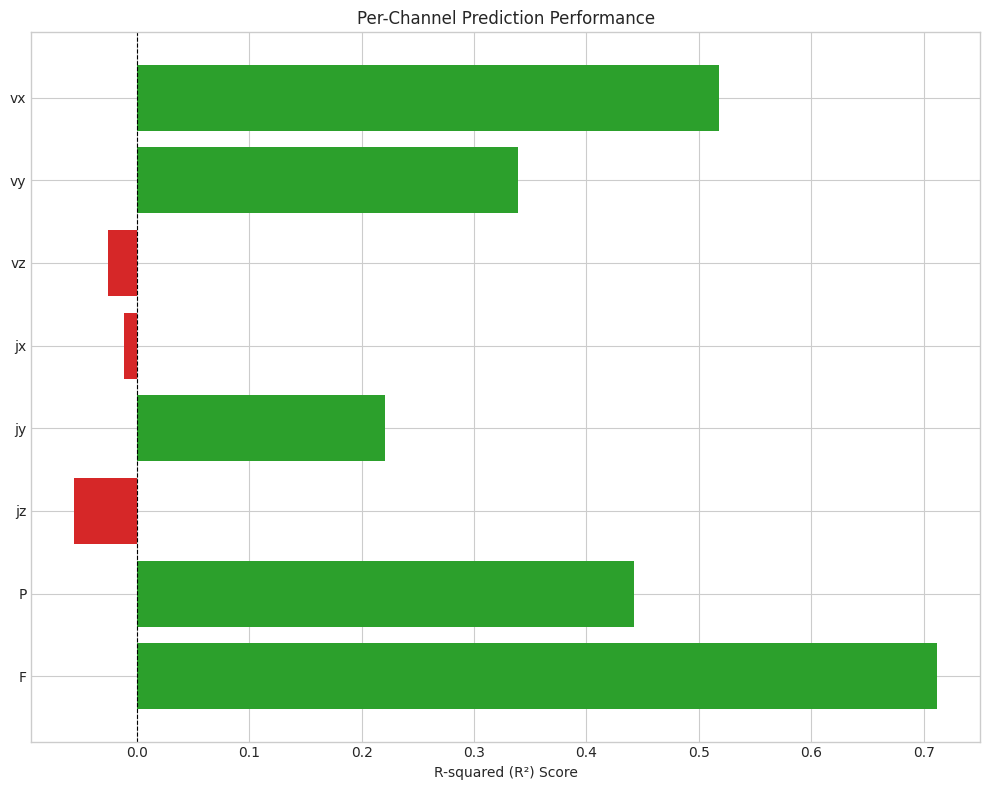

2025-07-08 15:47:05,941 - INFO - Loading prediction rollout error from /cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/experiments/study_1_param_sweep/output/param_sweep_07_07_25/lr_1e-4_ld_4096_wr_1.0_wp_1.0_wl_10.0_we_0.1/eval/prediction_rollout_error_train_val.npz...



--- Prediction Error Over Time ---


/cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/packages/mhd_surrogate_core/src/mhd_surrogate_core/plot.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])


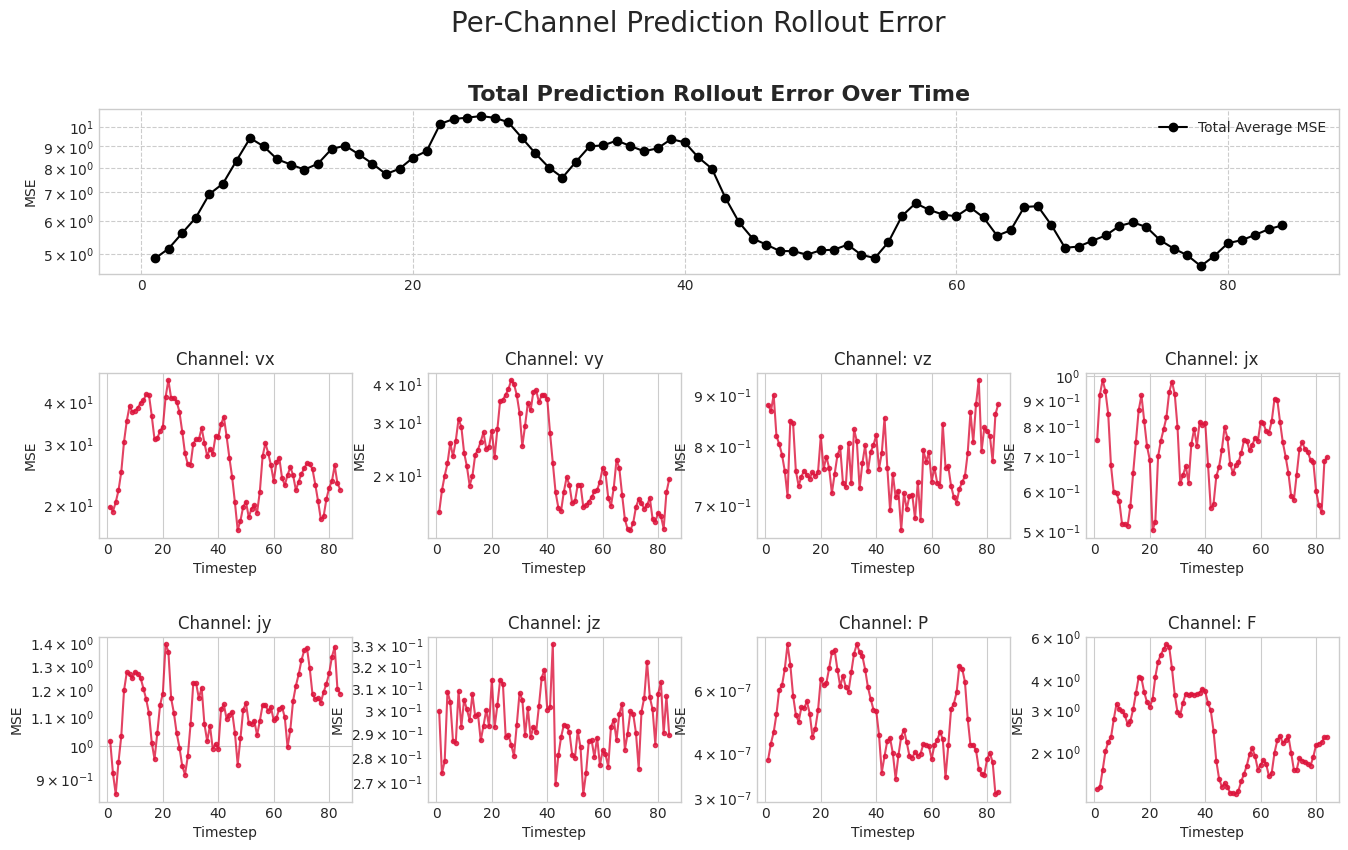

In [2]:
# Example path - update this to your specific run's output.
error_file_path = Path("/cephfs/users/skowronek/Documents/PhD/nuclear_fusion_cooling/prediction/mhd_surrogate_modelling/experiments/study_1_param_sweep/output/param_sweep_07_07_25/lr_1e-4_ld_4096_wr_1.0_wp_1.0_wl_10.0_we_0.1/eval/prediction_rollout_error_train_val.npz")

if error_file_path.exists():
    # --- Load all metrics from the file ---
    with np.load(error_file_path, allow_pickle=True) as data:
        channel_names = data['channel_names']
        r_squared_total = data['r_squared_total']
        r_squared_per_channel = data['r_squared_per_channel']
    
    # --- Display Summary Table ---
    print(f"--- PREDICTION SUMMARY ---")
    print(f"Overall R² Score: {r_squared_total:.4f}\n")
    
    # --- THE FIX IS HERE --- 
    # Generate both the bar chart and the error-over-time plot
    print("\n--- Average Prediction Performance (R²) ---")
    plot_r2_performance(error_file_path, eval_type="Prediction")
    
    print("\n--- Prediction Error Over Time ---")
    plot_prediction_rollout_error(error_file_path)
else:
    print(f"ERROR: Error file not found at {error_file_path}")